In [1]:
!pip install -q transformers datasets seqeval pandas matplotlib seaborn tqdm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Load Kannada NER CSV partitions
df_train = pd.read_csv("kn_train.csv")
df_val = pd.read_csv("kn_val.csv")
df_test = pd.read_csv("kn_test.csv")

print(f"Raw Train Shape: {df_train.shape}")
print(f"Raw Val Shape:   {df_val.shape}")
print(f"Raw Test Shape:  {df_test.shape}")
print("\nSample Row:")
print(df_train.head(1))

Raw Train Shape: (471763, 2)
Raw Val Shape:   (2381, 2)
Raw Test Shape:  (1019, 2)

Sample Row:
                 tokens     tags
0  ನಿರ್ದೇಶಕರುಃ ಶಿವಗಣೇಶ್  O B-PER


In [3]:
import unicodedata
import re
from tqdm import tqdm

def clean_kannada_row(tokens_str, tags_str):
    tokens = str(tokens_str).split()
    tags = str(tags_str).split()
    
    # Strictly ensure token and tag count parity
    if len(tokens) != len(tags) or len(tokens) == 0:
        return None
    
    cleaned_tokens = []
    cleaned_tags = []
    for tok, tag in zip(tokens, tags):
        # 1. Unicode NFC Normalization (preserves ottuakshara and virama marks)
        norm_tok = unicodedata.normalize('NFC', tok)
        # 2. Remove residual HTML / unprintable control characters
        norm_tok = re.sub(r'<[^>]+>', '', norm_tok)
        norm_tok = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', norm_tok).strip()
        
        if norm_tok:
            cleaned_tokens.append(norm_tok)
            cleaned_tags.append(tag)
            
    if not cleaned_tokens:
        return None
        
    return " ".join(cleaned_tokens), " ".join(cleaned_tags), len(cleaned_tokens)

def clean_dataset(df):
    clean_records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        res = clean_kannada_row(row['tokens'], row['tags'])
        if res is not None:
            clean_records.append(res)
            
    clean_df = pd.DataFrame(clean_records, columns=['tokens', 'tags', 'token_count'])
    return clean_df.drop_duplicates(subset=['tokens']).reset_index(drop=True)

print("Processing Train Split...")
df_train_clean = clean_dataset(df_train)
print("Processing Val Split...")
df_val_clean = clean_dataset(df_val)
print("Processing Test Split...")
df_test_clean = clean_dataset(df_test)

print(f"\nCleaned Row Counts -> Train: {len(df_train_clean)}, Val: {len(df_val_clean)}, Test: {len(df_test_clean)}")

Processing Train Split...


  0%|          | 0/471763 [00:00<?, ?it/s]

100%|██████████| 471763/471763 [01:15<00:00, 6282.72it/s]


Processing Val Split...


100%|██████████| 2381/2381 [00:00<00:00, 7061.74it/s]


Processing Test Split...


100%|██████████| 1019/1019 [00:00<00:00, 6047.69it/s]



Cleaned Row Counts -> Train: 464298, Val: 2380, Test: 1004


Entity Tag Distribution (Cleaned Train Split):
  O       : 3,467,119
  B-PER   : 304,572
  I-PER   : 265,088
  B-LOC   : 173,900
  B-ORG   : 163,833
  I-ORG   : 139,361
  I-LOC   : 44,578


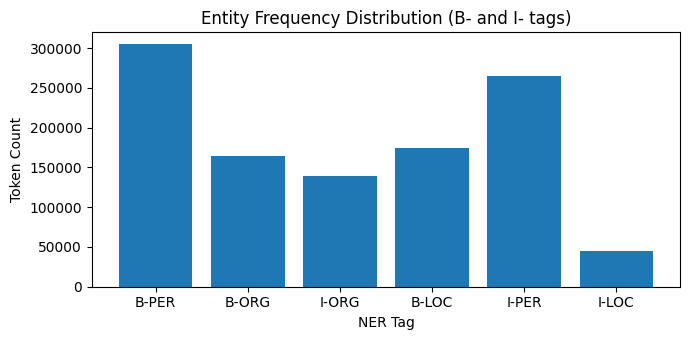

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

def get_tag_counts(df):
    tag_counter = Counter()
    for tag_seq in df['tags']:
        tag_counter.update(tag_seq.split())
    return tag_counter

tag_counts = get_tag_counts(df_train_clean)
print("Entity Tag Distribution (Cleaned Train Split):")
for tag, count in tag_counts.most_common():
    print(f"  {tag:<8}: {count:,}")

# Bar plot of entity distributions (excluding 'O' background tag for visibility)
entity_only = {k: v for k, v in tag_counts.items() if k != 'O'}
plt.figure(figsize=(7, 3.5))
plt.bar(entity_only.keys(), entity_only.values(), color='#1f77b4')
plt.title("Entity Frequency Distribution (B- and I- tags)")
plt.xlabel("NER Tag")
plt.ylabel("Token Count")
plt.tight_layout()
plt.savefig("entity_distribution.png", dpi=300)
plt.show()

100%|██████████| 25000/25000 [00:04<00:00, 5424.37it/s]



--- MuRIL Subword Sequence Length Analysis ---
Mean Subwords:     17.75
Median Subwords:   13
95th Percentile:   43
99th Percentile:   67
Max Subwords:      158
Coverage at max_length = 64: 98.89%
Coverage at max_length = 128: 99.98%
Coverage at max_length = 256: 100.00%


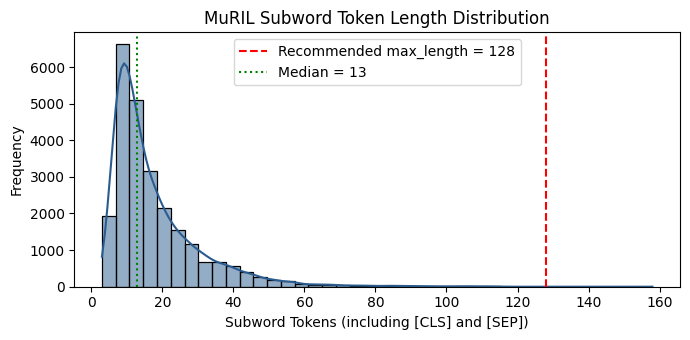

In [6]:
from transformers import AutoTokenizer
import numpy as np
import seaborn as sns

# Load Google MuRIL Tokenizer
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")

# Analyze sequence length expansion on a 25,000 sentence sample
sample_texts = df_train_clean['tokens'].sample(n=min(25000, len(df_train_clean)), random_state=42)
subword_lens = [len(tokenizer.encode(t, add_special_tokens=True)) for t in tqdm(sample_texts)]
subword_arr = np.array(subword_lens)

print("\n--- MuRIL Subword Sequence Length Analysis ---")
print(f"Mean Subwords:     {np.mean(subword_arr):.2f}")
print(f"Median Subwords:   {np.median(subword_arr):.0f}")
print(f"95th Percentile:   {np.percentile(subword_arr, 95):.0f}")
print(f"99th Percentile:   {np.percentile(subword_arr, 99):.0f}")
print(f"Max Subwords:      {np.max(subword_arr)}")

for limit in [64, 128, 256]:
    cov = (subword_arr <= limit).mean() * 100
    print(f"Coverage at max_length = {limit}: {cov:.2f}%")

# Generate sequence length histogram
plt.figure(figsize=(7, 3.5))
sns.histplot(subword_arr, bins=40, color="#2b5c8f", kde=True)
plt.axvline(x=128, color='red', linestyle='--', label='Recommended max_length = 128')
plt.axvline(x=np.median(subword_arr), color='green', linestyle=':', label=f'Median = {int(np.median(subword_arr))}')
plt.title("MuRIL Subword Token Length Distribution")
plt.xlabel("Subword Tokens (including [CLS] and [SEP])")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=300)
plt.show()

In [7]:
import json

# Save preprocessed partitions
df_train_clean.to_csv("kn_preprocessed_train.csv", index=False)
df_val_clean.to_csv("kn_preprocessed_val.csv", index=False)
df_test_clean.to_csv("kn_preprocessed_test.csv", index=False)

# Save metadata and pipeline statistics
stats = {
    "train_rows": len(df_train_clean),
    "val_rows": len(df_val_clean),
    "test_rows": len(df_test_clean),
    "mean_subwords": float(np.mean(subword_arr)),
    "median_subwords": int(np.median(subword_arr)),
    "p95_subwords": float(np.percentile(subword_arr, 95)),
    "recommended_max_length": 128,
    "coverage_pct": float((subword_arr <= 128).mean() * 100)
}

with open("preprocessing_stats.json", "w") as f:
    json.dump(stats, f, indent=4)

print("Saved clean CSVs and preprocessing_stats.json successfully!")

Saved clean CSVs and preprocessing_stats.json successfully!
